In [30]:
import numpy as np
import xgboost as xgb
import pandas as pd
import optuna
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

In [7]:
data_dir = "data/"
train_features = pd.read_csv(f'{data_dir}train_processed.csv')
train_consumption = pd.read_csv(f'{data_dir}train_hh_gt.csv')
train_features['cons_ppp17'] = train_consumption['cons_ppp17']
df_clean = train_features.dropna()
x=df_clean.drop(columns=['cons_ppp17','weight'])
y=df_clean[['cons_ppp17']]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)
x_train.shape , x_test.shape

((72888, 71), (31238, 71))

In [8]:
scaler = StandardScaler()
target_scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

y_train_scaled = target_scaler.fit_transform(y_train)
y_test_scaled = target_scaler.transform(y_test)

In [36]:
tune_train_x, tune_val_x,tune_train_y, tune_val_y =train_test_split(x_train_scaled, y_train_scaled,test_size=0.2,random_state=42)
tune_train_x.shape, tune_val_x.shape,tune_train_y.shape, tune_val_y.shape

((58310, 71), (14578, 71), (58310, 1), (14578, 1))

In [37]:
def run_experiment(trial):
    param_grid = {
        'objective': 'reg:squarederror',  
        'n_estimators': 4000,             
        'n_jobs': -1,                     
        'early_stopping_rounds': 50,
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1),
        'max_depth':trial.suggest_int('max_depth',3,10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree',0.6, 1.0),
        'reg_alpha':trial.suggest_float('reg_alpha',0.01,10.0,log=True),
        'reg_lambda':trial.suggest_float('reg_lambda',0.01,10.0,log=True),}

    model =xgb.XGBRegressor(**param_grid)
    model.fit(tune_train_x,tune_train_y,eval_set=[(tune_val_x, tune_val_y)],verbose=False)
    
    predictions = model.predict(tune_val_x)
    error_score = np.sqrt( mean_squared_error(tune_val_y,predictions))
    
    return error_score

In [38]:
study = optuna.create_study(direction ='minimize')

[I 2026-01-18 20:20:50,520] A new study created in memory with name: no-name-014b56db-d2b3-43d5-b5a3-ca39ca22c018


In [39]:
print("Running the optimization...")
study.optimize(run_experiment, n_trials=50)

Running the optimization...


[I 2026-01-18 20:20:58,875] Trial 0 finished with value: 0.6333711020688243 and parameters: {'learning_rate': 0.022756417218639753, 'max_depth': 5, 'subsample': 0.8726031722869361, 'colsample_bytree': 0.839821203453547, 'reg_alpha': 0.6515286022644455, 'reg_lambda': 0.06448151463291182}. Best is trial 0 with value: 0.6333711020688243.
[I 2026-01-18 20:21:07,427] Trial 1 finished with value: 0.6293691715936793 and parameters: {'learning_rate': 0.04004800960886309, 'max_depth': 6, 'subsample': 0.9199848434463771, 'colsample_bytree': 0.6962680722753238, 'reg_alpha': 5.55624604022562, 'reg_lambda': 4.484517997837196}. Best is trial 1 with value: 0.6293691715936793.
[I 2026-01-18 20:21:21,063] Trial 2 finished with value: 0.6331059921811449 and parameters: {'learning_rate': 0.0970367874830746, 'max_depth': 3, 'subsample': 0.9972600623992279, 'colsample_bytree': 0.8420723770822003, 'reg_alpha': 9.895954463060466, 'reg_lambda': 1.6369630439461784}. Best is trial 1 with value: 0.62936917159367

In [40]:
print("Best score found: ", study.best_value)
print("Best settings found: ", study.best_params)

Best score found:  0.6287336916783101
Best settings found:  {'learning_rate': 0.04518521531987444, 'max_depth': 7, 'subsample': 0.89990198904729, 'colsample_bytree': 0.6314442929568861, 'reg_alpha': 4.241348817004963, 'reg_lambda': 7.628745134922558}


In [41]:
best_params= study.best_params
best_params['n_estimators']=5000
best_params['objective']= 'reg:squarederror'

In [52]:
final_model = xgb.XGBRegressor(**best_params)
final_model.fit(x_train_scaled, y_train_scaled,eval_set=[(tune_val_x, tune_val_y)],verbose=False)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.6314442929568861
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [53]:
final_predictions=final_model.predict(x_test_scaled)

In [54]:
final_predictions

array([ 0.6897095 , -0.42694125, -0.79587656, ...,  3.0320141 ,
       -0.63547045,  1.6696626 ], shape=(31238,), dtype=float32)

In [55]:
y_test

,cons_ppp17
95707,21.519768
37103,5.152827
80314,4.126011
89152,15.130653
37001,5.971312
...,...
29263,9.936855
17555,6.567615
50021,39.253872
42605,2.099588


In [50]:
import matplotlib.pyplot as plt

In [57]:
y_pred_original = target_scaler.inverse_transform(final_predictions.reshape(-1, 1))

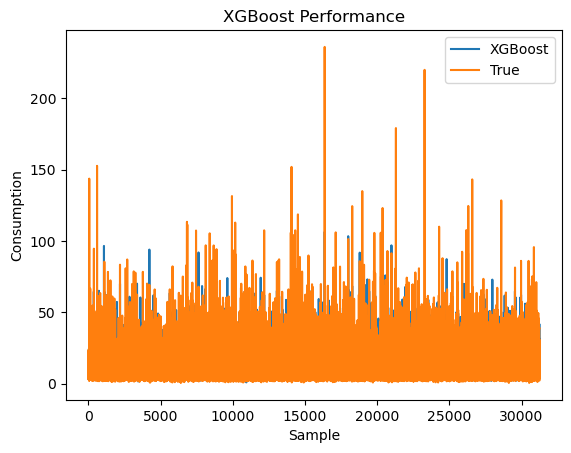

In [62]:
plt.plot(y_pred_original, label='XGBoost')
plt.plot(y_test.values, label='True')
plt.title('XGBoost Performance')
plt.xlabel('Sample')
plt.ylabel('Consumption')
plt.legend()
plt.show()

In [58]:
mse_list = []
mae_list = []
r2_list = []
models = []

In [59]:
y_pred_fixed = np.maximum(y_pred_original, 0)
mse = mean_squared_error(y_test, y_pred_fixed)
mae =mean_absolute_error(y_test, y_pred_fixed)
r2=r2_score(y_test, y_pred_fixed)

mse_list.append(mse)
mae_list.append(mae)
r2_list.append(r2)
models.append('XGBoost')

print(f'MSE: {mse:.2f}, MAE: {mae:.2f}, R2: {r2:.2f}')

MSE: 44.56, MAE: 3.76, R2: 0.57


In [60]:
final_model.save_model("tuned_xgboost_model.json")
#loaded_model.load_model("tuned_xgboost_model.json")